# 13 — Do the learned features preserve useful movement differences?

A masking task can become easier while a useful movement difference
becomes harder to predict. This notebook makes that possibility visible
by evaluating two connected operations: predicting hidden teacher
features, and predicting an observable movement score from a frozen
encoder. Notebook 14 separately examines observable future movement.

We first check the evaluation with a signal whose meaning we know, then
train the two small masking examples introduced in Notebook 12. Every
executed output below is calculated from generated data in this execution.
The final section separately reviews the retained real-data comparison
from Notebook 12, so its findings are not attributed to these examples.
Three optimizer updates are enough to exercise the pathway, but provide
no assessment of a fully trained masking method.

You can run this notebook independently in a fresh kernel. It imports
the helpers introduced in Notebooks 11 and 12 and prepares its own
synthetic examples. The final section shows how the same evaluation
connects this evaluation with the completed real-data experiments.

## 1. Keep the prediction question visible

| Question | Input to the predictor | Measured outcome |
|---|---|---|
| Can the JEPA complete its training task? | Online encoder features with selected observations hidden | Features supplied by that model's teacher |
| Do frozen features help describe movement? | The same five bilateral feature summaries for every encoder | The original recording's coordinate-derived laterality score |
| Do predicted future features express future movement? | A JEPA prediction based on a past-only prefix | Future landmark coordinates, studied in Notebook 14 |

The first outcome changes when a model's teacher changes. The second
gives every method the same target and therefore supports the main
comparison of usefulness. For example, two teachers could differ in
how much their features vary; predicting a nearly constant teacher
could require little movement information.

The original score describes a signed left–right movement difference
computed from estimated coordinates. Its predictability does not by
itself establish neurological interpretation or diagnostic usefulness.

In [1]:
from pathlib import Path
import copy
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from IPython import get_ipython
from matplotlib_inline.backend_inline import set_matplotlib_formats
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("svg", "png")

SUITE_ROOT = next(
    candidate
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for candidate in (parent, parent / "neurips-laterality")
    if (candidate / "laterality" / "model.py").is_file()
)
if str(SUITE_ROOT) not in sys.path:
    sys.path.insert(0, str(SUITE_ROOT))

from notebook_progress import NotebookTaskProgress
from laterality.metrics import source_weights, weighted_r2
from laterality_extensions.masked_learning import LearningSettings, load_learning_dataset
from laterality_extensions.comparative_training import default_conditions, train_comparison
from laterality_extensions.comparative_evaluation import (
    aggregate_predictions, evaluate_frozen_representations, feature_diagnostics,
    fit_source_readout, make_evaluation_mask_bank, paired_source_bootstrap,
    predictor_diagnostics, prepare_raw_missing_observations,
    prepared_observation_sensitivity,
)

torch.set_num_threads(1)
tutorial_progress = NotebookTaskProgress(
    "Masking encoder and predictor evaluation tutorial", unit_name="stage",
)
tutorial_progress.start(
    10, profile="synthetic evaluation",
    note="Tracking the tutorial checks, training updates, and diagnostic summaries",
)
print("Synthetic teaching examples; no real-data training is enabled.")

Synthetic teaching examples; no real-data training is enabled.


## 2. Check that the readout can recover a known signal

Suppose two measured feature channels describe left and right movement,
and the target is twice the first channel minus half the second. We
generate this relation directly, so a linear readout should recover it.
Two additional channels contain irrelevant variation; some values in
one channel are missing. This lets us exercise training-only imputation
as well as regression.

Six generated sources supply training clips and two supply test clips.
Within the training sources, we choose the ridge penalty by repeatedly
holding out whole sources. Each inner split fits its own imputation
and scaling. We pool the inner predictions before comparing penalties,
refit the chosen readout on the outer training sources, and evaluate
the remaining sources once. A failure here would raise a software or
evaluation concern before we interpreted any weak encoder result.

In [2]:
with tutorial_progress.unit(1, "Check the source-aware read-out on a known signal"):
    rng = np.random.default_rng(81)
    signal_sources = np.repeat(np.array(list("abcdefgh")), 5)
    signal_features = rng.normal(size=(40, 4))
    signal_target = 2 * signal_features[:, 0] - 0.5 * signal_features[:, 1]
    signal_features[::3, 3] = np.nan
    signal_readout = fit_source_readout(
        signal_features, signal_target, signal_sources,
        train_sources=tuple("abcdef"), test_sources=tuple("gh"),
        alphas=(0.001, 0.1, 10), inner_folds=3,
    )
    signal_test = np.isin(signal_sources, tuple("gh"))
    recovered_signal = signal_readout.predict(signal_features[signal_test])
    signal_r2 = weighted_r2(
        signal_target[signal_test], recovered_signal,
        source_weights(signal_sources[signal_test]),
    )
    display(pd.DataFrame([{
        "Example": "Known linear movement signal",
        "Test clips": int(signal_test.sum()), "Test sources": 2,
        "R²": signal_r2, "Selected ridge penalty": signal_readout.selected_alpha,
    }]).round(3))
    assert np.mean((recovered_signal - signal_target[signal_test]) ** 2) < 0.01

,Example,Test clips,Test sources,R²,Selected ridge penalty
0,Known linear movement signal,10,2,1.0,0.001


The readout recovers the constructed signal on 10 test examples from
two generated sources, with R² rounding to 1.000 and a selected ridge
penalty of 0.001. The rounded score should not be read as proof of zero
error. We supplied a linear relation that this readout can express.

This constructed result establishes that the readout procedure can
recover a signal expressed by its inputs. It does not establish that
a real encoder preserves that signal. We use the same source-separated
procedure below, including for direct pose summaries and the initial
encoder, so a method receives no special tuning advantage.

The validation here selects a supervised readout after pretraining.
Choosing an entire pretraining recipe would require an additional
source boundary: inner validation videos must also be excluded from
training each candidate encoder. Selecting a mask using outer-test
scores would defeat the comparison's intended separation.

## 3. Prepare two matched encoders and declared checkpoints

We use 33 input landmarks and compare scattered targets from the twelve
gait landmarks with scattered targets from all landmarks. Both models
retain the twelve-landmark regularizer and five-pair laterality summary.
This changes the eligible prediction targets while preserving the
other anatomical choices.

The three-update teaching run stores states after updates 1 and 3.
Update 3 is the declared evaluation checkpoint; update 1 is retained
to demonstrate inspection and recovery of a specified earlier state.
We pair initial weights, sampled source clips, geometric views, and
hidden-token counts before interpreting the comparison.

In [3]:
with tutorial_progress.unit(
    2, "Train the matched synthetic encoders", total_steps=6,
) as progress:
    dataset = load_learning_dataset(real=False, fold=0)
    settings = LearningSettings(steps=3, batch_size=4, embed_dim=8, heads=2, seed=7)
    conditions = default_conditions()

    condition_order = tuple(conditions)
    def report_training(update):
        condition_index = condition_order.index(update["condition"])
        completed = condition_index * update["total_steps"] + update["step"]
        progress.update_unit(
            completed_steps=completed,
            detail=(f"{update['condition'].replace('_', ' ')} · "
                    f"update {update['step']}/{update['total_steps']} · "
                    f"loss {update['loss']:.4f}"),
        )

    comparison = train_comparison(
        dataset, settings, conditions, checkpoint_steps=(1, 3),
        progress_callback=report_training,
    )
    assert all(comparison["pairing"].values())
    display(pd.DataFrame([
        {"Control": key.replace("_", " "), "Paired": value}
        for key, value in comparison["pairing"].items()
    ]))

    checkpoint_rows = []
    for name, run in comparison["runs"].items():
        for step, state in run["checkpoints"].items():
            checkpoint_rows.append({
                "Masking condition": name.replace("_", " "), "Update": step,
                "Online encoder stored": any(key.startswith("view_encoder.") for key in state),
                "Teacher stored": any(key.startswith("target_encoder.") for key in state),
            })
    display(pd.DataFrame(checkpoint_rows))
    first_run = next(iter(comparison["runs"].values()))
    earlier_model = copy.deepcopy(first_run["model"])
    earlier_model.load_state_dict(first_run["checkpoints"][1], strict=True)

,Control,Paired
0,same initialization,True
1,same projector initialization,True
2,same source draws,True
3,same geometric views,True
4,same hidden counts,True


,Masking condition,Update,Online encoder stored,Teacher stored
0,gait targets,1,True,True
1,gait targets,3,True,True
2,all landmark targets,1,True,True
3,all landmark targets,3,True,True


All five pairing checks pass in the retained execution. The two
conditions therefore started with the same encoder, predictor, and
regularizer-projector weights and received matched clips, geometric
views, and hidden counts. The checkpoint table also confirms that both
encoder states were stored after the two declared updates. These are
checks of the comparison's construction; prediction is evaluated below.

The online encoder receives gradients. The teacher follows the online
encoder through an exponential moving average and supplies targets
without receiving gradients. These two stored states can differ even
when their architecture is identical. We fit separate frozen readouts
for them, while preserving the usual online-encoder input to the JEPA
predictor. Feeding teacher features into that predictor would introduce
another experimental change.

## 4. Give every model the same evaluation gaps

The bank below contains scattered gaps and one consecutive missing
region on each leg. A leg region contains the knee, ankle, heel, and
foot tip, joined through explicit anatomical connections. Both sides
are tested. The scattered condition matches the left-region hidden
count for each clip; naturally missing measurements can give the right
region a different count, which we record.

The masks are generated once from validity and a separate evaluation
seed, then reused for every model. A deliberately hidden observation
remains a valid teacher target during the feature-prediction diagnostic.
Naturally missing observations cannot supply such a target. Requested
leg regions keep their complete pattern even when some measurements
were already missing. We count valid hidden targets separately; a
corruption that removes no observed token is recorded as infeasible.

In [4]:
patch_valid = dataset.valid.reshape(len(dataset.xyz), -1, 4, 33).all(axis=2)
evaluation_masks = make_evaluation_mask_bank(patch_valid, seed=813, interval_length=1)
with tutorial_progress.unit(
    3, "Verify evaluation-mask coverage", total_steps=len(evaluation_masks),
) as progress:
    coverage_rows = []
    for mask_index, (name, mask) in enumerate(evaluation_masks.items(), start=1):
        for row in dataset.test_rows:
            coverage_rows.append({
                "Gap": name.replace("_", " "),
                "Requested missing positions": int(mask[row].sum()),
                "Hidden valid tokens": int((mask[row] & patch_valid[row]).sum()),
                "Remaining valid tokens": int((patch_valid[row] & ~mask[row]).sum()),
                "Feasible target": bool((mask[row] & patch_valid[row]).any()
                                        and (patch_valid[row] & ~mask[row]).any()),
            })
        progress.update_unit(
            completed_steps=mask_index, detail=f"Checked {name.replace('_', ' ')}",
        )
    display(pd.DataFrame(coverage_rows).groupby("Gap", as_index=False).agg(
        smallest_hidden_count=("Hidden valid tokens", "min"),
        largest_hidden_count=("Hidden valid tokens", "max"),
        smallest_remaining_context=("Remaining valid tokens", "min"),
        feasible_clips=("Feasible target", "sum"),
    ))

,Gap,smallest_hidden_count,largest_hidden_count,smallest_remaining_context,feasible_clips
0,left leg gap,4,4,128,11
1,right leg gap,4,4,128,11
2,scattered gap,4,4,128,11


## 5. Inspect feature prediction together with variation

The coverage table above shows that every evaluation pattern hides four
valid tokens and leaves 128 in each of the 11 test clips. Thus this
synthetic example compares gap shapes at the same count, removing about
3% of its input tokens. It tests a small interruption in observation,
rather than an entire missing leg or a long unobserved interval.

The predictor receives hidden online-encoder inputs and predicts the
matching teacher vectors. We calculate squared error per hidden token,
average within each clip, then give each source the same total weight.
The normalized error divides this quantity by the correspondingly
weighted mean squared teacher-channel value. That denominator controls
magnitude; it does not make different teachers equivalent outcomes.

We also compare each prediction with a teacher target from another
evaluation source, at the same valid landmark and time positions. This
fixed-seed diagnostic breaks the clip correspondence without fitting
any new parameters. A similar error for correct and mismatched targets
would weaken the case that predictions retain clip-specific content.
We compare the correct and mismatched errors on the same clips when
missing observations limit this control's availability. The initial
model supplies another reference.

In [5]:
diagnostic_models = [("Initial model", first_run["initial_model"])] + [
    (name.replace("_", " "), run["model"])
    for name, run in comparison["runs"].items()
]
with tutorial_progress.unit(
    4, "Run predictor diagnostics", total_steps=len(diagnostic_models),
) as progress:
    diagnostic_tables = []
    for model_index, (name, model) in enumerate(diagnostic_models, start=1):
        diagnostic_tables.append(predictor_diagnostics(
            model, dataset, evaluation_masks, condition=name,
        ))
        progress.update_unit(completed_steps=model_index, detail=f"Evaluated {name}")
    feature_results = pd.concat(diagnostic_tables, ignore_index=True)
    diagnostic_labels = {
        "condition": "Training condition", "evaluation_mask": "Evaluation gap",
        "evaluated_sources": "Sources", "mismatch_control_clips": "Control clips",
        "matched_target_mse_on_control_clips": "Correct target error",
        "mismatched_target_mse": "Mismatched target error",
        "target_clip_mean_channel_sd": "Teacher feature spread",
        "prediction_clip_mean_channel_sd": "Predicted feature spread",
    }
    display(feature_results[list(diagnostic_labels)].rename(columns=diagnostic_labels).round(3))

,Training condition,Evaluation gap,Sources,Control clips,Correct target error,Mismatched target error,Teacher feature spread,Predicted feature spread
0,Initial model,left_leg_gap,5,11,1.115,1.115,0.003,0.001
1,Initial model,right_leg_gap,5,11,1.126,1.126,0.004,0.001
2,Initial model,scattered_gap,5,11,0.944,0.944,0.389,0.015
3,gait targets,left_leg_gap,5,11,1.027,1.027,0.003,0.001
4,gait targets,right_leg_gap,5,11,1.057,1.057,0.004,0.001
5,gait targets,scattered_gap,5,11,0.877,0.877,0.389,0.015
6,all landmark targets,left_leg_gap,5,11,1.087,1.087,0.003,0.001
7,all landmark targets,right_leg_gap,5,11,1.095,1.095,0.004,0.001
8,all landmark targets,scattered_gap,5,11,0.883,0.883,0.389,0.017


In this three-update example, correct and mismatched errors round to
the same value in every displayed row. For the left-leg gap, gait-target
training reduces feature error from about 1.12 to 1.03, but a teacher
target from another source also gives about 1.03. This brief execution
therefore does not show that the reduced error depends on matching the
particular recording. Its role is to make that check inspectable.

The displayed errors use the same control clips. Feature spread is the
mean standard deviation across feature channels, with equal total
weight per source. The full table also retains normalized errors,
feature norms, covariance effective rank,
unavailable clips, and near-constant-feature flags. Effective rank
describes how many feature directions carry appreciable variation.
It is computed from covariance eigenvalues and has no clinical scale.
We inspect both individual token vectors and a mean vector per clip,
because variation across landmark positions can coexist with little
variation between recordings. Different hidden locations can also
affect the clip averages, so these remain diagnostic descriptions. For
example, the initial teacher's spread is already about 0.389 for the
scattered mask, compared with 0.003–0.004 for the fixed leg regions.
Changing which landmark vectors are averaged can create this difference
before any training, so it cannot establish learned movement variation.

The following failure case produces no between-clip variation. A
predictor matching these constant targets could have zero feature
error while conveying no differences among the clips. A lower feature
loss alone therefore cannot rank the usefulness of independently
learned teachers. A shared frozen teacher would support a separately
trained comparison with a common target space.

In [6]:
with tutorial_progress.unit(5, "Verify the constant-feature collapse check"):
    constant_features = np.ones((8, 4))
    constant_check = feature_diagnostics(constant_features, np.array(list("abcdefgh")))
    display(pd.DataFrame([constant_check]).round(3))
    assert constant_check["near_constant"]

,mean_channel_sd,mean_feature_norm,effective_rank,near_constant,variation_floor,examples,sources
0,0.0,2.0,0.0,True,0.0,8,8


## 6. Predict the same movement score from each frozen representation

The preceding constant-feature check reports zero spread, zero effective
rank, and a positive near-constant flag. Its feature norm is still 2: a
vector can have nonzero magnitude while being identical for every clip.
This explains why we inspect variation beside feature prediction error.

We fit the online, teacher, and initial-encoder readouts separately.
Direct pose summaries give a reference using input measurements without
a learned encoder. The mean target from training sources gives a
prediction with no clip-specific information. Every fitted readout
uses the same inner source splits and ridge-penalty candidates.

To test prepared-coordinate sensitivity, we also remove the fixed bank's
observations from already prepared test inputs. The readouts remain
those fitted on unaltered training inputs, and the target remains the
original recording's movement score. This asks whether missing features
disrupt an existing predictor; the following section separately checks
removal before input preparation.

In [7]:
sensitivity_inputs = {
    name + "_prepared_sensitivity": prepared_observation_sensitivity(dataset, mask)
    for name, mask in evaluation_masks.items()
}
with tutorial_progress.unit(
    6, "Evaluate the frozen representations", total_steps=len(comparison["runs"]),
) as progress:
    evaluated = {}
    for run_index, (name, run) in enumerate(comparison["runs"].items(), start=1):
        evaluated[name] = evaluate_frozen_representations(
            run["model"], run["initial_model"], dataset, settings,
            condition=name, checkpoint="update_3", alphas=(0.01, 1.0, 100.0),
            observation_datasets=sensitivity_inputs,
            comparison_id="synthetic_three_update_masking_example",
        )
        progress.update_unit(
            completed_steps=run_index, detail=f"Evaluated {name.replace('_', ' ')}",
        )
    predictions = pd.concat([result["predictions"] for result in evaluated.values()], ignore_index=True)
    expected = pd.DataFrame({
        "sequence_id": dataset.sequence_ids[dataset.test_rows],
        "source_id": dataset.source_ids[dataset.test_rows], "fold": dataset.fold,
    })
    representations = ("pretrained_online", "pretrained_teacher", "initial_online", "direct_pose", "training_mean")
    scores = aggregate_predictions(
        predictions, expected, seeds=(settings.seed,), conditions=tuple(conditions),
        representations=representations,
        observations=("unaltered", *sensitivity_inputs),
    )
    display(scores["per_seed"].query("observation == 'unaltered'")[[
        "condition", "representation", "r2", "mae", "evaluated_clips", "evaluated_sources",
    ]].round(3))

,condition,representation,r2,mae,evaluated_clips,evaluated_sources
3,all_landmark_targets,direct_pose,0.433,0.029,11,5
7,all_landmark_targets,initial_online,0.014,0.040,11,5
11,all_landmark_targets,pretrained_online,0.023,0.040,11,5
15,all_landmark_targets,pretrained_teacher,0.014,0.040,11,5
19,all_landmark_targets,training_mean,-0.098,0.042,11,5
23,gait_targets,direct_pose,0.433,0.029,11,5
27,gait_targets,initial_online,0.014,0.040,11,5
31,gait_targets,pretrained_online,0.030,0.040,11,5
35,gait_targets,pretrained_teacher,0.014,0.040,11,5
39,gait_targets,training_mean,-0.098,0.042,11,5


For these 11 synthetic test clips from five sources, direct pose
summaries give R² = 0.433 and mean absolute error 0.029. The initial
encoder gives R² = 0.014; after three updates, the online encoders give
0.030 with gait targets and 0.023 with all-landmark targets. Their
absolute errors all round to 0.040, and the teachers remain close to
the initial encoder. The direct inputs are the more useful representation
in this small example; the encoder differences require the uncertainty
check below and cannot establish a real-data masking preference.

Source-balanced R² measures predictive fit while giving every source
video the same total influence. A negative score means the squared
error exceeds that of a constant equal to the evaluated targets' mean;
that reference mean defines the metric and is never a fitted prediction
baseline. The separately reported training-mean predictor uses only
training targets. Mean absolute error gives the average size of an
error in the movement score's original units.

This example contains one declared outer fold and one training seed.
In the full comparison, each seed must contribute predictions from all
five outer folds before R² is computed. We then summarize these five
seed-specific scores. Averaging fold R² values would change the metric;
averaging predictions across seeds would instead evaluate an ensemble.
The coverage check rejects duplicate rows, source overlap, or missing
declared predictions before a complete comparison is reported.

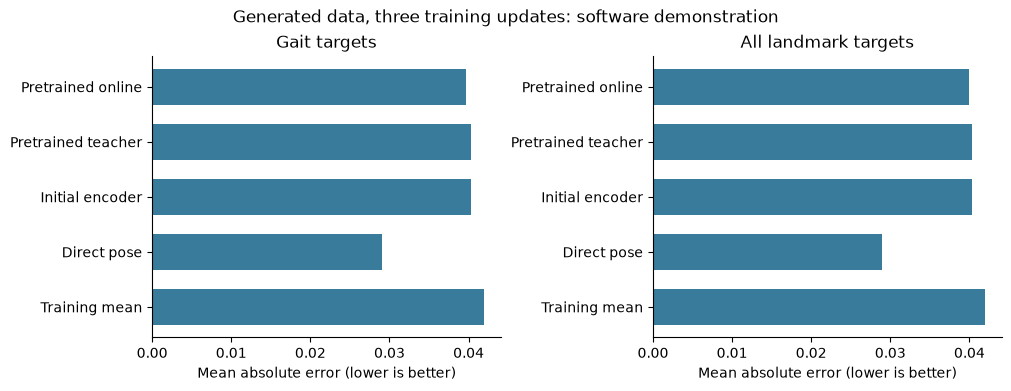

In [8]:
with tutorial_progress.unit(7, "Plot the frozen-representation comparison"):
    readable_names = {
        "pretrained_online": "Pretrained online", "pretrained_teacher": "Pretrained teacher",
        "initial_online": "Initial encoder", "direct_pose": "Direct pose", "training_mean": "Training mean",
    }
    intact = scores["per_seed"].query("observation == 'unaltered'")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
    for ax, condition in zip(axes, conditions):
        rows = intact[intact.condition == condition].set_index("representation").loc[list(representations)]
        ax.barh(np.arange(len(rows)), rows.mae, color="#387b9a", height=0.65)
        ax.set_yticks(np.arange(len(rows)), [readable_names[name] for name in rows.index])
        ax.invert_yaxis()
        ax.set_xlabel("Mean absolute error (lower is better)")
        ax.set_title(condition.replace("_", " ").capitalize())
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("Generated data, three training updates: software demonstration", fontsize=12)
    plt.show()

The two plots show why the small R² differences should not dominate
the interpretation: pretrained and initial feature errors are close,
while direct pose summaries give a visibly lower error. The repeated
control bars contain the same predictions in both panels; they provide
a shared reference, not additional independent experiments. A useful real-data result
would require better prediction across excluded source videos, with
comparable coverage and uncertainty, under the declared training budget.

If teacher prediction becomes easier but both frozen readouts remain
weak, the current feature objective has not established useful movement
learning. If the initial encoder performs similarly, the learned
changes have not demonstrated added value. Improvement only when a
specific region is missing would support a more limited sensitivity
finding that should be reported at that observation condition.

In [9]:
with tutorial_progress.unit(8, "Summarize masking sensitivity"):
    sensitivity = scores["per_seed"].query("representation == 'pretrained_online'")
    display(sensitivity[[
        "condition", "observation", "mae", "evaluated_clips", "evaluated_sources", "unavailable_clips",
    ]].round(3))

,condition,observation,mae,evaluated_clips,evaluated_sources,unavailable_clips
8,all_landmark_targets,left_leg_gap_prepared_sensitivity,0.064,11,5,0
9,all_landmark_targets,right_leg_gap_prepared_sensitivity,0.072,11,5,0
10,all_landmark_targets,scattered_gap_prepared_sensitivity,0.050,11,5,0
11,all_landmark_targets,unaltered,0.040,11,5,0
28,gait_targets,left_leg_gap_prepared_sensitivity,0.062,11,5,0
29,gait_targets,right_leg_gap_prepared_sensitivity,0.069,11,5,0
30,gait_targets,scattered_gap_prepared_sensitivity,0.049,11,5,0
31,gait_targets,unaltered,0.040,11,5,0


## 7. Remove raw observations before normalization and interpolation

The sensitivity table above retains all 11 test clips from five sources.
For both online encoders, hiding a short leg region raises mean absolute
error from about 0.040 to 0.062–0.072; scattered gaps give about
0.049–0.050. Because all three masks hide four tokens, their geometry
affects this synthetic predictor even at a small missing fraction. The
gait-target model has slightly lower errors in this execution, but one
brief training run cannot establish an advantage under real occlusion.

Removing coordinates after normalization can leave information from
hidden measurements inside the remaining input. For example, a removed
hip could already have contributed to the pelvis center or body scale.
A claim about genuinely missing measurements requires removal before
those calculations.

The next independent example constructs raw coordinates with visibility
values, removes a fixed ankle interval, and calls the existing pose
preparation using only remaining observations. Changing the withheld
coordinates cannot change the prepared result. The original movement
score is supplied separately and remains unchanged. Short gaps may be
interpolated from permitted endpoints, so we report raw removed counts
separately from prepared valid-token counts.

In [10]:
with tutorial_progress.unit(9, "Check the raw-coordinate missingness boundary"):
    raw_rng = np.random.default_rng(11)
    raw = raw_rng.normal(size=(16, 33, 4))
    raw[..., 3] = 1
    raw[:, 23, :3] = [-0.5, 0, 0]
    raw[:, 24, :3] = [0.5, 0, 0]
    withheld = np.zeros((16, 33), dtype=bool)
    withheld[4:12, [27, 29, 31]] = True
    preparation = dict(original_target=0.2, frames=16, max_interpolation_gap=2)
    prepared = prepare_raw_missing_observations(raw, np.arange(16), 30, withheld, **preparation)
    changed = raw.copy()
    changed[withheld, :3] = 10000
    prepared_again = prepare_raw_missing_observations(changed, np.arange(16), 30, withheld, **preparation)
    np.testing.assert_array_equal(prepared["xyz"], prepared_again["xyz"])
    np.testing.assert_array_equal(prepared["valid"], prepared_again["valid"])
    display(pd.DataFrame([{key: value for key, value in prepared.items() if key not in ("xyz", "valid")}]))

,target,available,naturally_missing_observations,deliberately_removed_observations,remaining_raw_observations,prepared_valid_tokens,input_preparation
0,0.2,True,0,24,504,126,raw removal before interpolation and normaliza...


This raw example removes 24 landmark observations, leaving 504 raw
observations and 126 valid four-step tokens after preparation. The two
assertions pass after the withheld coordinates are replaced with very
large values, confirming that those values do not enter the prepared
input. The reference score of 0.2 was supplied to the example and kept
fixed; this cell does not estimate or reconstruct that movement score.

The raw example tests the missing-information boundary. The sensitivity
scores above use already prepared synthetic inputs and retain that
narrower interpretation. A real missing-data evaluation must build each
corrupted input from its raw archive with this boundary, retain the
unaltered recording's target, and apply the same prepared inputs to
every model. Cases with no usable input remain explicit unavailable
predictions, with their source and coverage information retained.

## 8. Keep source uncertainty separate from training variation

To compare the two masking conditions, we resample complete source
videos. Each sampled source carries all its clips, both methods, and
every seed's prediction together. We calculate the metric within each
seed and average the paired differences. The interval conditions on
the fitted models; it does not estimate what would happen if models
were retrained on every resampled cohort.

The example uses 100 resamples to keep execution small. Its tiny test
set and one synthetic training seed cannot support a research claim.
A real analysis should predeclare its larger resampling budget and
report seed variability separately. Sign agreement, when added, also
needs a declared near-zero exclusion rule: a tiny signed target can
change direction under a small measurement error.

In [11]:
with tutorial_progress.unit(10, "Estimate paired source-level uncertainty"):
    uncertainty = paired_source_bootstrap(
        predictions, first="all_landmark_targets", reference="gait_targets",
        representation="pretrained_online", repetitions=100,
    )
    display(pd.DataFrame([uncertainty]).round(3))

tutorial_progress.complete(status="Tutorial complete")

,difference,lower_95,upper_95,metric,subtraction,sources,clips_per_seed,seeds,requested_resamples,finite_resamples,uncertainty_scope
0,-0.007,-0.028,0.017,r2,all_landmark_targets minus gait_targets,5,11,1,100,100,source resampling conditional on fitted models...


The displayed synthetic difference is all-landmark minus gait-target
R²: −0.007, with a source-resampling interval from −0.028 to 0.017.
Values on either side of zero remain compatible with this small
comparison. The point estimate alone does not select a masking policy.

## 9. Connect the example with the completed real-data comparison

Notebook 12 displays the real experiment's aggregate counts before
training can start, beginning with the retained 1,200-update recipe;
its plan object also retains the complete fold/seed/condition table.
Its real runner saves compatible trained states in a separate location.
The same `evaluate_frozen_representations` call used above evaluates
each declared fold, training seed, and checkpoint. Per-clip prediction
files must retain source, fold, seed, condition, reference target, and
availability before their results are aggregated.

Evaluate the predeclared checkpoint and observation bank consistently.
Refit each imputer, scaler, and selected ridge readout using that fold's
training sources. Pool all outer predictions within each seed, include
initial, direct-pose, and training-mean controls, then report the shared
observable outcome alongside feature diagnostics. The exploratory GAVD
results already examined have informed this development; independent
recordings would strengthen a later confirmation.

A separate completed real-data run is now retained through
[Notebook 12](12_controlled_masking_pretraining.ipynb): two masking
conditions, five outer source groups, and five training seeds, with
1,200 updates per encoder. It evaluates 625 clips from 93 source videos.
The following interpretation comes from those saved predictions and
diagnostics, independently checked against their summary. None of the
executed outputs above comes from that real-data run.

The real predictors distinguish correctly paired teacher targets from
targets taken from other videos across all tested fold/seed pairs and
evaluation masks. This shows that feature prediction acquired
recording-related information. It does not identify that information as
laterality: posture, camera view, or other differences between recordings
could also help distinguish the targets. The observable movement
readouts provide the necessary additional check.

For the unaltered recordings, the mean source-balanced R² is about
−0.027 for the gait-target online encoder and −0.020 for the
all-landmark online encoder, compared with +0.048 for their matched
initial encoder and +0.130 for direct pose summaries. The teachers also
remain below zero on average. Both kinds of pretrained features score
below the matched initial features in each of the five training seeds.
The modest numerical advantage of all-landmark over gait targets is
uncertain: the retained teacher-readout comparison gives a difference
of +0.012, with a 95% source-resampling interval of −0.018 to +0.050.
These intervals condition on the fitted models and are not estimates
of uncertainty from repeating the entire training process.

Readout selection leaves an important next question. Every initial and
trained-online fit selects the largest offered ridge penalty, 100;
49 of the 50 teacher fits do the same. A larger training-only search
range is therefore warranted before attributing weak movement
prediction to discarded encoder information. The present result
concerns the features together with the tested readout procedure.
Future settings should be selected within training sources, with
independent evaluation needed to strengthen a claim informed by these
already inspected GAVD results.

The real missing-observation evaluation is also narrow: it removes
roughly 0.9% of valid prepared tokens in a typical clip. Three clips
cannot supply the requested left-leg or scattered corruption, and
four cannot supply the right-leg corruption because no observed token
would be removed. Their rows remain explicit in the results. Small
changes in already weak predictive scores on the remaining clips do
not establish resilience to substantial occlusion, and preparing the
input after raw observation removal remains a separate evaluation.
The [research tutorial](docs/TUTORIAL.md) places these findings and
their numerical evidence in the broader sequence of experiments.